# 20 - The Linear Products and Operations

This notebook is a standalone, executable replacement for Chapter 20 of *Geometric Algebra for Computer Science*. It keeps the chapter's implementation focus but rewrites the exposition in a notebook style: each idea is paired with code that builds the object being discussed, saves a durable artifact, and checks an invariant.

Source audit before authoring: the textbook table of contents anchors Chapter 20 at printed page 521 and Chapter 21 at printed page 529. Local extraction with `pdftotext` shows Chapter 20 text on physical PDF pages 542 through 548, corresponding to printed pages 521 through 527. Physical PDF page 549 begins Chapter 21 at printed page 529, so printed page 528 has no extractable chapter text in this PDF copy. I therefore treat printed pages 521-527 as the text span and record printed page 528 as blank or omitted in the audit artifact.

The aim here is not to reproduce the book's prose. The aim is to make the implementation contract active: a multivector is a coordinate vector once a basis list is fixed; a left factor can be converted into a matrix that acts on a right factor; products such as outer product and contraction are grade-selected versions of the geometric product; and a sparse list of weighted basis blades is often the more practical data structure.

## The Chapter Idea In One Picture

The central move of this chapter is to look at products as linear maps. Fix a basis list `L`. A multivector `A` is stored as a coordinate column, and multiplying by `A` on the left becomes a matrix that acts on the coordinate column for `B`. The entries of that matrix are not arbitrary. They are made from the structure coefficients of the algebra: the small signed numbers that say which basis blade appears when one basis blade multiplies another.

That perspective is useful for two reasons. First, it translates geometric algebra into familiar linear algebra. If you know how to multiply a matrix by a vector, you already know the execution shape of `A * B` once the operator matrix for `A` has been assembled. Second, it exposes why a direct dense matrix approach is usually not the final implementation strategy. A full product matrix has `4^n` scalar slots in an `n`-dimensional vector space, while typical geometric objects use a small fraction of the `2^n` basis blades. The sparse list of basis blades does the same distributive work while avoiding many zeros.

Read the notebook with two questions in mind: what needs to be precomputed from the algebra, and what needs to be recomputed when the input multivector changes? Structure coefficients and basis order are algebra-level facts. The numeric entries of the matrix for a particular `A` are input-level facts. Sparse products skip the matrix and distribute directly over the nonzero basis blades.

## Translation Guide

| Geometric algebra idea | Implementation object in this notebook | Why it matters |
|---|---|---|
| Basis list `L` | A fixed ordered list of basis-blade bit masks | Coordinates only mean something after the basis order is fixed. |
| Multivector `A` | A dense vector or sparse `{mask: coefficient}` dictionary | Dense vectors are simple; sparse dictionaries reveal the actual work. |
| Structure coefficient | A row `(left, right, output, coefficient)` | This is the atom used to fill product matrices and product tables. |
| Geometric product matrix for `A` | `algebra.left_operator_matrix(A, kind="geometric")` | Matrix times coordinates gives the same result as distributing over basis blades. |
| Outer product | Grade `grade(left) + grade(right)` part of the geometric product | In this basis order the operator matrix is lower triangular. |
| Left contraction | Grade `grade(right) - grade(left)` part, when that grade is possible | It keeps the part that removes the left grade from the right grade. |
| Right contraction | Grade `grade(left) - grade(right)` part, when that grade is possible | It is a different grade selection and therefore a different matrix. |
| Grade projection | A diagonal selection matrix | Unary linear operations can be matrices too. |
| Sparse list approach | Double loop over nonzero weighted basis blades | This is the practical bridge toward specialized generated code. |

The helper module intentionally avoids a full geometric algebra library. It implements the small kernel this chapter needs: bit-mask basis blades, products under a symmetric metric, grade selections, product matrices, product tables, sparse distribution, and sanity checks.

## Notebook Route

1. Import the helper module and set stable artifact directories under `artifacts/chapter-20`.
2. Record the verified PDF and printed-page span used for this chapter replacement.
3. Build the basis list `L` and inspect the coordinate contract.
4. Implement unary linear operations as diagonal matrices: grade projection, reversion, grade involution, and Clifford conjugation.
5. Construct product matrices from structure coefficients and compare them with sparse distribution.
6. Inspect product tables and matrix sparsity patterns for geometric, outer, left contraction, and right contraction products.
7. Work a vector-versus-blade contraction example and a non-diagonal metric example.
8. Compare dense-matrix storage with sparse-list work, then save implementation reports.
9. Run final invariants and assert that the promised artifacts exist.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
from IPython.display import Image, Markdown, display

BOOK_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils" / "chapter20_linear_products.py").exists():
        BOOK_ROOT = candidate
        break

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.chapter20_linear_products import (
    EPS,
    LinearProductAlgebra,
    basis_table_rows,
    coefficient_bar_figure,
    format_terms,
    grade_projection_figure,
    matrix_density,
    matrix_entry_rows,
    operation_profile_figure,
    operation_profile_rows,
    operator_heatmap_figure,
    product_table_figure,
    sanity_checks,
    save_json,
    save_matplotlib_png,
    save_plotly_html,
    sparsity_comparison_figure,
    storage_growth_figure,
    storage_growth_rows,
)

ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "chapter-20"
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"
for directory in (FIGURES, TABLES, CHECKS):
    directory.mkdir(parents=True, exist_ok=True)


def rel(path: Path) -> str:
    return path.relative_to(BOOK_ROOT).as_posix()


def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(str(row.get(column, "")) for column in columns) + " |" for row in rows]
    return "\n".join([header, separator, *body])

print(f"Project root: {BOOK_ROOT}")
print(f"Artifact root: {rel(ARTIFACT_ROOT)}")


Project root: D:\Geometry\Geometric-Algebra-for-Computer-Science
Artifact root: artifacts/chapter-20


## Source Span Audit

The source span matters because this repository is replacing one chapter at a time. If the PDF page offset drifts, a worker could accidentally summarize the previous or next chapter. The audit below records both page systems: physical PDF pages, which tools use, and printed pages, which the book uses. The content used for this notebook is the Chapter 20 span, not Chapter 19's basis-blade algorithms and not Chapter 21's nonlinear algorithms.

The audit is intentionally small and machine-readable. It does not store extracted textbook text. It stores the extraction decision: which physical pages were inspected, which printed pages they correspond to, and how the missing printed page 528 was handled.

In [2]:
source_audit = {
    "source_pdf": "Geometric Algebra for Computer Science.pdf",
    "requested_printed_pages": "521-528",
    "verified_text_span": "printed 521-527 on physical PDF pages 542-548",
    "printed_page_528_status": "No extractable Chapter 20 text found; physical PDF page 549 begins Chapter 21 at printed page 529.",
    "verified_pages": [
        {"printed_page": 521, "pdf_page": 542, "content": "Chapter 20 opener"},
        {"printed_page": 522, "pdf_page": 543, "content": "linear algebra approach and unary operations"},
        {"printed_page": 523, "pdf_page": 544, "content": "grade extraction and product matrices"},
        {"printed_page": 524, "pdf_page": 545, "content": "structure coefficients and matrix assembly"},
        {"printed_page": 525, "pdf_page": 546, "content": "example product matrices"},
        {"printed_page": 526, "pdf_page": 547, "content": "sparsity and list of basis blades approach"},
        {"printed_page": 527, "pdf_page": 548, "content": "outer product loop and structural exercises"},
    ],
    "verification_commands": [
        "pdfinfo <book.pdf>",
        "pdftotext -layout -f 542 -l 548 <book.pdf> -",
        "pdftotext -layout -f 549 -l 549 <book.pdf> -",
    ],
}
source_audit_path = save_json(source_audit, CHECKS / "source-page-audit.json")
assert source_audit["verified_pages"][0]["printed_page"] == 521
assert source_audit["verified_pages"][-1]["printed_page"] == 527
assert source_audit["verified_pages"][-1]["pdf_page"] == 548
rel(source_audit_path)


'artifacts/chapter-20/checks/source-page-audit.json'

## Basis List And Coordinate Contract

A coordinate vector is only meaningful after we choose the basis list. The textbook writes this list as `L`: a row whose entries are the basis blades. This notebook orders basis blades by grade and then by bitmap value. For 3D Euclidean space that gives scalar, vectors, bivectors, and pseudoscalar in a single fixed sequence.

The bit-mask encoding is compact. The scalar has mask `000`. The vector `e1` has mask `001`, `e2` has mask `010`, and `e3` has mask `100`. A blade with several basis vectors uses the bitwise union of those vectors, so `e1e3` has mask `101`. This mask is not a geometric object by itself; it is an implementation label. The metric and the product rules decide how those labels multiply.

The table below is the coordinate contract for the rest of the notebook. Every dense multivector array is interpreted in this order. Every product matrix has rows and columns in this same order. If a matrix row is labeled `e1e2`, the entry in that row contributes to the `e1e2` coordinate of the output.

In [3]:
algebra = LinearProductAlgebra.from_signature((1.0, 1.0, 1.0), names=("e1", "e2", "e3"))
basis_rows = basis_table_rows(algebra.dimension, algebra.names)
basis_path = save_json(basis_rows, TABLES / "basis-order.json")

display(Markdown(markdown_table(basis_rows, ["index", "mask", "binary", "grade", "label"])))
assert algebra.blade_names == [row["label"] for row in basis_rows]
assert [row["grade"] for row in basis_rows] == sorted(row["grade"] for row in basis_rows)
rel(basis_path)


| index | mask | binary | grade | label |
| --- | --- | --- | --- | --- |
| 0 | 0 | 000 | 0 | 1 |
| 1 | 1 | 001 | 1 | e1 |
| 2 | 2 | 010 | 1 | e2 |
| 3 | 4 | 100 | 1 | e3 |
| 4 | 3 | 011 | 2 | e1e2 |
| 5 | 5 | 101 | 2 | e1e3 |
| 6 | 6 | 110 | 2 | e2e3 |
| 7 | 7 | 111 | 3 | e1e2e3 |

'artifacts/chapter-20/tables/basis-order.json'

## Linear Operations As Diagonal Matrices

Addition and scalar multiplication are almost too simple: add coordinate vectors, or scale every coordinate. The more interesting unary operations are still linear. Reversion, grade involution, and Clifford conjugation are diagonal sign matrices because each basis blade is returned to itself with a grade-dependent sign. Grade projection is also diagonal: keep coordinates of one grade and zero the rest.

This is a useful implementation lesson. Before thinking about products, many operations can be represented as fixed matrices that depend only on the basis list. They do not depend on the numeric multivector. For a small teaching algebra this matrix view is transparent. In performance code the same idea can be compiled into sign flips and coordinate copies.

The next cell builds a mixed-grade multivector, saves a coefficient chart, saves a grade-energy chart, and verifies that summing all grade projections reconstructs the original multivector. That reconstruction check is the executable version of the statement that the grade subspaces form a direct coordinate decomposition.

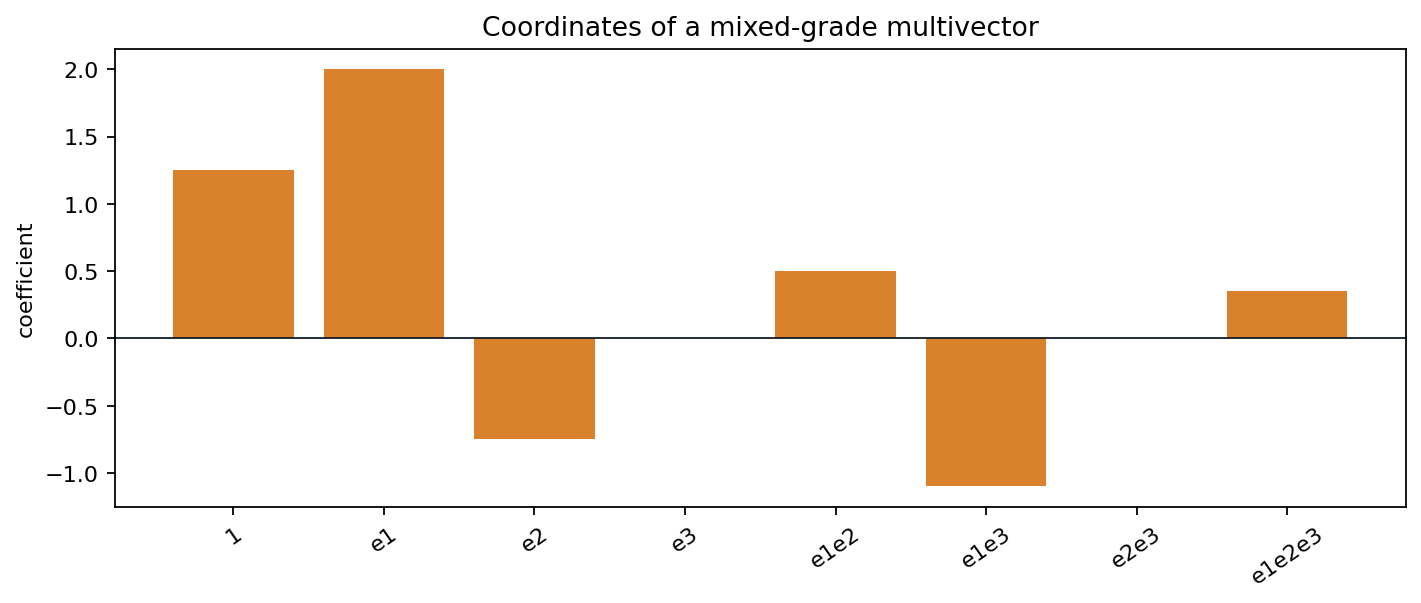

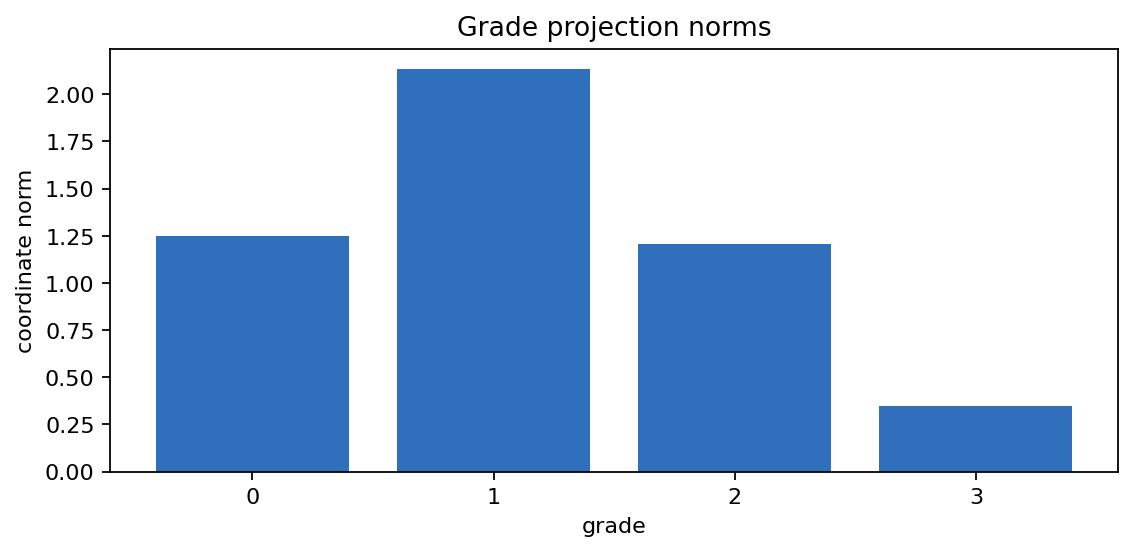

artifacts/chapter-20/tables/grade-projection-report.json


In [4]:
A = (
    1.25 * algebra.scalar(1.0)
    + 2.0 * algebra.basis_dense(0b001)
    - 0.75 * algebra.basis_dense(0b010)
    + 0.5 * algebra.basis_dense(0b011)
    - 1.1 * algebra.basis_dense(0b101)
    + 0.35 * algebra.basis_dense(0b111)
)

projection_sum = sum(algebra.project_grade(A, target) for target in range(algebra.dimension + 1))
assert np.allclose(projection_sum, A)
assert np.allclose(algebra.reverse(algebra.reverse(A)), A)
assert np.allclose(algebra.grade_involution(algebra.grade_involution(A)), A)

coefficient_path = save_matplotlib_png(
    coefficient_bar_figure(algebra, A, title="Coordinates of a mixed-grade multivector"),
    FIGURES / "mixed-grade-coordinates.png",
)
grade_energy_path = save_matplotlib_png(
    grade_projection_figure(algebra, A, title="Grade projection norms"),
    FIGURES / "grade-projection-energy.png",
)
projection_report = {
    "A": algebra.coefficient_rows(A),
    "reverse_A": algebra.coefficient_rows(algebra.reverse(A)),
    "grade_0": algebra.coefficient_rows(algebra.project_grade(A, 0)),
    "grade_1": algebra.coefficient_rows(algebra.project_grade(A, 1)),
    "grade_2": algebra.coefficient_rows(algebra.project_grade(A, 2)),
    "grade_3": algebra.coefficient_rows(algebra.project_grade(A, 3)),
}
projection_path = save_json(projection_report, TABLES / "grade-projection-report.json")

display(Image(filename=str(coefficient_path), width=780))
display(Image(filename=str(grade_energy_path), width=680))
print(rel(projection_path))


## Product Matrices From Structure Coefficients

Now we turn from unary operations to bilinear products. The geometric product is linear in each argument. If the left argument `A` is fixed, the function `B -> A * B` is a linear map, so it has a matrix in our chosen basis. The matrix entries are assembled from basis-blade products. For every left basis blade `L_k` and right basis blade `L_j`, the product contributes one or more output basis blades with scalar coefficients. Those coefficients are the structure coefficients.

For an orthonormal Euclidean metric, a basis-blade geometric product has one output blade with coefficient `+1` or `-1`. For a non-diagonal metric, a basis-blade product can expand into several terms. The helper supports both, so the matrix assembly rule stays the same: loop over left slots, loop over right slots, multiply basis blades, and add the weighted coefficient to the output row.

The following worked example compares two paths: `M_A @ B`, where `M_A` is the geometric product matrix for `A`, and direct sparse distribution over nonzero basis blades. They must agree coordinate by coordinate. The product table is saved as interactive HTML so you can hover over any basis-basis entry.

In [5]:
B = (
    -0.4 * algebra.scalar(1.0)
    + 1.1 * algebra.basis_dense(0b010)
    + 0.8 * algebra.basis_dense(0b100)
    - 0.6 * algebra.basis_dense(0b011)
    + 0.25 * algebra.basis_dense(0b110)
)

gp_matrix = algebra.left_operator_matrix(A, kind="geometric")
gp_matrix_result = gp_matrix @ B
gp_sparse_result = algebra.dense_product(A, B, kind="geometric")
assert np.allclose(gp_matrix_result, gp_sparse_result)

product_table_path = save_plotly_html(
    product_table_figure(algebra, kind="geometric"),
    FIGURES / "geometric-product-table.html",
)
gp_matrix_path = save_plotly_html(
    operator_heatmap_figure(algebra, gp_matrix, title="Geometric product matrix for A"),
    FIGURES / "geometric-product-matrix-for-A.html",
)
product_report = {
    "A": algebra.coefficient_rows(A),
    "B": algebra.coefficient_rows(B),
    "A_times_B": algebra.coefficient_rows(gp_sparse_result),
    "matrix_density": matrix_density(gp_matrix),
}
product_report_path = save_json(product_report, TABLES / "geometric-product-worked-example.json")

display(Markdown(markdown_table(product_report["A_times_B"], ["index", "label", "grade", "coefficient"])))
print(rel(product_table_path))
print(rel(gp_matrix_path))
print(rel(product_report_path))
product_table_figure(algebra, kind="geometric")


| index | label | grade | coefficient |
| --- | --- | --- | --- |
| 0 | 1 | 0 | -1.025 |
| 1 | e1 | 1 | -1.6675 |
| 2 | e2 | 1 | 0.475 |
| 3 | e3 | 1 | 1.0225 |
| 4 | e1e2 | 2 | 1.805 |
| 5 | e1e3 | 2 | 1.78 |
| 6 | e2e3 | 2 | 0.3725 |
| 7 | e1e2e3 | 3 | 1.97 |

artifacts/chapter-20/figures/geometric-product-table.html
artifacts/chapter-20/figures/geometric-product-matrix-for-A.html
artifacts/chapter-20/tables/geometric-product-worked-example.json


## Product Tables, Sparse Patterns, And The First Column Test

The geometric product matrix is the broadest of the linear product matrices. The outer product, left contraction, right contraction, scalar product, and commutator product can all be built by changing which grade parts survive. This is why their matrices look like the geometric product matrix with systematic zeros inserted.

Three structural tests are especially good for implementation work. First, the first column of the geometric product matrix for `A` is `A`, because multiplying on the right by the scalar basis blade `1` returns `A`. Second, the same first-column test holds for the outer product with scalar `1`. Third, it does not hold for the left contraction: only the scalar part of `A` can contract into a scalar on the right. These tests catch basis-order mistakes quickly.

The outer product has another visual signature. With grade-ordered coordinates, it is lower triangular: a left factor of positive grade can only move the right input to a higher grade, while a scalar left factor stays on the diagonal. This lower-triangular pattern is a coordinate shadow of the fact that the outer product builds higher-grade blades.

In [6]:
matrices = {
    "geometric": algebra.left_operator_matrix(A, kind="geometric"),
    "outer": algebra.left_operator_matrix(A, kind="outer"),
    "left contraction": algebra.left_operator_matrix(A, kind="left_contraction"),
    "right contraction": algebra.left_operator_matrix(A, kind="right_contraction"),
}
sparsity_path = save_plotly_html(
    sparsity_comparison_figure(algebra, matrices),
    FIGURES / "product-matrix-sparsity.html",
)

density_rows = [
    {
        "kind": kind,
        "nonzeros": int(np.count_nonzero(np.abs(matrix) > EPS)),
        "density": round(matrix_density(matrix), 4),
    }
    for kind, matrix in matrices.items()
]
density_path = save_json(density_rows, TABLES / "product-matrix-density.json")

scalar_column = algebra.index(0)
expected_left_contraction_first_column = np.zeros(algebra.size)
expected_left_contraction_first_column[algebra.index(0)] = A[algebra.index(0)]
assert np.allclose(matrices["geometric"][:, scalar_column], A)
assert np.allclose(matrices["outer"][:, scalar_column], A)
assert np.allclose(matrices["left contraction"][:, scalar_column], expected_left_contraction_first_column)
assert np.count_nonzero(np.abs(np.triu(matrices["outer"], k=1)) > EPS) == 0

display(Markdown(markdown_table(density_rows, ["kind", "nonzeros", "density"])))
print(rel(sparsity_path))
print(rel(density_path))
sparsity_comparison_figure(algebra, matrices)


| kind | nonzeros | density |
| --- | --- | --- |
| geometric | 48 | 0.75 |
| outer | 21 | 0.3281 |
| left contraction | 21 | 0.3281 |
| right contraction | 21 | 0.3281 |

artifacts/chapter-20/figures/product-matrix-sparsity.html
artifacts/chapter-20/tables/product-matrix-density.json


## Left And Right Contraction Matrices

Contractions are not interchangeable names for the same operation. In this notebook the left contraction of a homogeneous left blade into a homogeneous right blade keeps the grade `grade(right) - grade(left)` part of their geometric product, and only when that grade is possible. The right contraction keeps `grade(left) - grade(right)` instead. Once multivectors contain several grades, the product is computed by distributing across homogeneous basis blades and applying the rule term by term.

A familiar vector identity becomes an implementation check. For a vector `a` and a blade `B`, the geometric product splits into a grade-lowering part and a grade-raising part: `a * B = left_contraction(a, B) + outer(a, B)`. This check is intentionally limited to a vector on the left and a homogeneous blade on the right. A general multivector product is a sum of many grade interactions, so the same two-term split is not a universal matrix identity.

The cell below works that vector-blade case and then contrasts the matrices for left and right contraction using the same fixed left bivector. If the two matrices were accidentally implemented with the same grade selection, this cell would fail.

In [7]:
a_vector = algebra.vector([0.75, -1.25, 0.5])
B_blade = 1.4 * algebra.basis_dense(0b011) - 0.8 * algebra.basis_dense(0b101)

vector_blade_gp = algebra.dense_product(a_vector, B_blade, kind="geometric")
vector_blade_lc = algebra.dense_product(a_vector, B_blade, kind="left_contraction")
vector_blade_op = algebra.dense_product(a_vector, B_blade, kind="outer")
assert np.allclose(vector_blade_gp, vector_blade_lc + vector_blade_op)

fixed_bivector = 1.2 * algebra.basis_dense(0b011) + 0.7 * algebra.basis_dense(0b110)
left_contract_matrix = algebra.left_operator_matrix(fixed_bivector, kind="left_contraction")
right_contract_matrix = algebra.left_operator_matrix(fixed_bivector, kind="right_contraction")
assert not np.allclose(left_contract_matrix, right_contract_matrix)

contraction_rows = {
    "a_times_B": algebra.coefficient_rows(vector_blade_gp),
    "left_contraction_a_B": algebra.coefficient_rows(vector_blade_lc),
    "outer_a_B": algebra.coefficient_rows(vector_blade_op),
    "right_contraction_matrix_entries": matrix_entry_rows(algebra, right_contract_matrix)[:24],
}
contraction_path = save_json(contraction_rows, TABLES / "contraction-worked-example.json")
contraction_sparsity_path = save_plotly_html(
    sparsity_comparison_figure(
        algebra,
        {
            "left contraction by bivector": left_contract_matrix,
            "right contraction by bivector": right_contract_matrix,
        },
    ),
    FIGURES / "left-right-contraction-sparsity.html",
)

display(Markdown("**Vector-blade split**\n\n" + markdown_table(contraction_rows["a_times_B"], ["label", "grade", "coefficient"])))
print(rel(contraction_path))
print(rel(contraction_sparsity_path))
sparsity_comparison_figure(
    algebra,
    {
        "left contraction by bivector": left_contract_matrix,
        "right contraction by bivector": right_contract_matrix,
    },
)


**Vector-blade split**

| label | grade | coefficient |
| --- | --- | --- |
| e1 | 1 | 2.15 |
| e2 | 1 | 1.05 |
| e3 | 1 | -0.6 |
| e1e2e3 | 3 | -0.3 |

artifacts/chapter-20/tables/contraction-worked-example.json
artifacts/chapter-20/figures/left-right-contraction-sparsity.html


## Non-Diagonal Metrics: One Basis Product Can Become A Sum

In a diagonal Euclidean metric, multiplying two basis blades produces a single basis blade with a sign. That pleasant simplification is not the full story. With a non-diagonal symmetric metric, a vector can have a nonzero inner product with a different basis vector. Then a basis-blade geometric product can contain both an outer part and a contraction part.

For example, if the metric has `g12 = 0.25`, then `e1 * e2` contains a scalar contribution from the metric and a bivector contribution from the outer product. The product matrix assembly rule does not need to change. The only difference is that the basis-basis product returns more than one output term, and each term contributes to a row of the operator matrix.

This is one reason the structure-coefficient viewpoint is valuable. It separates the algebra-specific table of basis products from the linear algebra act of accumulating matrix entries. The code below uses the same helper functions with a non-diagonal metric and verifies matrix multiplication against sparse distribution again.

In [8]:
skew_metric = np.array(
    [
        [1.0, 0.25, 0.0],
        [0.25, 1.0, -0.15],
        [0.0, -0.15, 1.0],
    ]
)
skew_algebra = LinearProductAlgebra(skew_metric, names=("e1", "e2", "e3"))
skew_left = 0.6 * skew_algebra.scalar(1) + skew_algebra.vector([1.0, -0.5, 0.2])
skew_right = -0.3 * skew_algebra.scalar(1) + skew_algebra.vector([0.4, 1.1, -0.7])

skew_pair_terms = skew_algebra.basis_product_terms(0b001, 0b010, kind="geometric")
assert 0 in skew_pair_terms and 0b011 in skew_pair_terms
skew_matrix = skew_algebra.left_operator_matrix(skew_left, kind="geometric")
skew_matrix_result = skew_matrix @ skew_right
skew_sparse_result = skew_algebra.dense_product(skew_left, skew_right, kind="geometric")
assert np.allclose(skew_matrix_result, skew_sparse_result)

skew_report = {
    "metric": skew_metric,
    "e1_times_e2": format_terms(skew_pair_terms, skew_algebra.names),
    "left": skew_algebra.coefficient_rows(skew_left),
    "right": skew_algebra.coefficient_rows(skew_right),
    "product": skew_algebra.coefficient_rows(skew_sparse_result),
}
skew_report_path = save_json(skew_report, TABLES / "non-diagonal-metric-report.json")
skew_matrix_path = save_plotly_html(
    operator_heatmap_figure(skew_algebra, skew_matrix, title="Geometric product matrix with non-diagonal metric"),
    FIGURES / "non-diagonal-geometric-product-matrix.html",
)

display(Markdown(f"`e1 * e2` in this metric = `{skew_report['e1_times_e2']}`"))
print(rel(skew_report_path))
print(rel(skew_matrix_path))
operator_heatmap_figure(skew_algebra, skew_matrix, title="Geometric product matrix with non-diagonal metric")


`e1 * e2` in this metric = `0.25 + e1e2`

artifacts/chapter-20/tables/non-diagonal-metric-report.json
artifacts/chapter-20/figures/non-diagonal-geometric-product-matrix.html


## The Sparse List Of Basis Blades Approach

The dense matrix view is clean, but it pays for every coordinate whether the input uses it or not. The sparse list approach stores only nonzero weighted basis blades. A product is a double loop over the nonzero terms of the left and right multivectors. Each pair calls the basis-blade product routine and accumulates like terms.

This is not yet the fastest possible implementation. It still performs dynamic loops, dictionary accumulation, and simplification. But it has the right shape for geometric algebra data: blades often live in one grade, rotors often live in even grades, and many model-specific objects have only a few coordinates. A dense `32 x 32` product matrix in 5D has 1024 scalar entries. A product of two four-term sparse multivectors checks only 16 basis pairs.

Chapter 22 will push this further through specialization and code generation. Here we stop at the conceptual bridge: the sparse product and the dense operator matrix are two implementations of the same linear product, and they should agree exactly up to floating-point roundoff.

In [9]:
ga5 = LinearProductAlgebra.from_signature((1, 1, 1, 1, 1), names=("e1", "e2", "e3", "e4", "e5"))
A5_sparse = {0: 1.0, 0b00001: 1.5, 0b00110: -0.75, 0b11000: 0.4}
B5_sparse = {0b00010: -1.2, 0b00100: 0.9, 0b01001: 0.6, 0b11100: -0.35}
A5 = ga5.sparse_to_dense(A5_sparse)
B5 = ga5.sparse_to_dense(B5_sparse)

A5_matrix_product = ga5.left_operator_matrix(A5, kind="geometric") @ B5
A5_sparse_product = ga5.sparse_to_dense(ga5.sparse_product(A5_sparse, B5_sparse, kind="geometric"))
assert np.allclose(A5_matrix_product, A5_sparse_product)

profile_rows = operation_profile_rows(ga5, A5, B5)
storage_rows = storage_growth_rows(max_dimension=10, active_terms=len(A5_sparse))
profile_path = save_json(profile_rows, TABLES / "sparse-operation-profile.json")
storage_path = save_json(storage_rows, TABLES / "storage-growth.json")
profile_figure_path = save_plotly_html(
    operation_profile_figure(profile_rows),
    FIGURES / "sparse-operation-profile.html",
)
storage_figure_path = save_plotly_html(
    storage_growth_figure(storage_rows),
    FIGURES / "storage-growth.html",
)

display(Markdown(markdown_table(profile_rows, ["kind", "matrix_nonzeros", "matrix_density", "sparse_pairs_checked", "output_terms"])))
print(rel(profile_path))
print(rel(storage_path))
print(rel(profile_figure_path))
print(rel(storage_figure_path))
operation_profile_figure(profile_rows)


| kind | matrix_nonzeros | matrix_density | sparse_pairs_checked | output_terms |
| --- | --- | --- | --- | --- |
| geometric | 128 | 0.125 | 16 | 11 |
| outer | 64 | 0.0625 | 16 | 9 |
| left_contraction | 64 | 0.0625 | 16 | 5 |
| right_contraction | 11 | 0.0107 | 16 | 2 |

artifacts/chapter-20/tables/sparse-operation-profile.json
artifacts/chapter-20/tables/storage-growth.json
artifacts/chapter-20/figures/sparse-operation-profile.html
artifacts/chapter-20/figures/storage-growth.html


## Applied Lab: From Product Tables To Generated Kernels

A symbolic product matrix can be viewed as a recipe. Each nonzero structure-coefficient row says: multiply one coordinate of the left factor by one coordinate of the right factor, scale by a sign or metric coefficient, and add it to one output coordinate. Dense matrix multiplication hides that recipe inside a generic linear algebra routine. Sparse and generated implementations expose it.

The lab below writes the structure-coefficient rows for four product kinds. For 3D Euclidean space the geometric product has one nonzero structure coefficient for every basis-basis pair, while outer product and contractions have fewer because grade selection turns many entries into zero. A code generator could use these rows to emit straight-line statements such as `out[i] += c * a[k] * b[j]`, then simplify away zero and constant cases.

This is also a useful debugging artifact. If an output coordinate has the wrong sign, the structure table tells you which basis pair contributed that sign. If a contraction returns a grade that should be impossible, the contraction structure table will show exactly where the bad selection entered.

In [10]:
structure_reports = {}
for kind in ("geometric", "outer", "left_contraction", "right_contraction"):
    rows = algebra.structure_coefficient_rows(kind=kind)
    structure_reports[kind] = {
        "row_count": len(rows),
        "first_rows": rows[:16],
    }
    save_json(rows, TABLES / f"structure-coefficients-{kind}.json")

structure_summary = [
    {"kind": kind, "nonzero_structure_rows": report["row_count"]}
    for kind, report in structure_reports.items()
]
structure_summary_path = save_json(structure_summary, TABLES / "structure-coefficient-summary.json")

display(Markdown(markdown_table(structure_summary, ["kind", "nonzero_structure_rows"])))
assert structure_reports["geometric"]["row_count"] == algebra.size * algebra.size
assert structure_reports["outer"]["row_count"] < structure_reports["geometric"]["row_count"]
assert structure_reports["left_contraction"]["row_count"] < structure_reports["geometric"]["row_count"]
rel(structure_summary_path)


| kind | nonzero_structure_rows |
| --- | --- |
| geometric | 64 |
| outer | 27 |
| left_contraction | 27 |
| right_contraction | 27 |

'artifacts/chapter-20/tables/structure-coefficient-summary.json'

## Implementation Checks You Can Port

A chapter replacement should not just show pictures. It should leave behind checks that a later implementation can steal. The helper's `sanity_checks()` function runs the same family of invariants across the code path: matrix products equal sparse products, grade projections reconstruct the original multivector, reversion is an involution, the vector-blade split holds in its proper setting, the first-column tests hold, and a non-diagonal metric still agrees between matrix and sparse execution.

The checks are numerical rather than symbolic because implementation bugs usually show up as wrong signs, wrong rows, wrong grade filters, or basis-order mismatches. Those are exactly the mistakes that small random coordinate tests catch well. The threshold is tight enough for these small matrices: all reported errors should be near roundoff.

In [11]:
check_results = sanity_checks()
check_path = save_json(check_results, CHECKS / "linear-products-sanity-checks.json")
for name, error in check_results.items():
    assert error < 1e-9, f"{name} too large: {error}"

display(Markdown(markdown_table([{"check": key, "error": f"{value:.3e}"} for key, value in check_results.items()], ["check", "error"])))
rel(check_path)


| check | error |
| --- | --- |
| geometric_matrix_sparse_error | 9.019e-16 |
| outer_matrix_sparse_error | 2.483e-16 |
| left_contraction_matrix_sparse_error | 0.000e+00 |
| right_contraction_matrix_sparse_error | 5.551e-17 |
| scalar_matrix_sparse_error | 0.000e+00 |
| grade_projection_reconstruction_error | 0.000e+00 |
| reversion_involution_error | 0.000e+00 |
| vector_blade_split_error | 0.000e+00 |
| first_gp_column_error | 0.000e+00 |
| first_outer_column_error | 0.000e+00 |
| first_left_contraction_column_error | 0.000e+00 |
| nondiagonal_metric_matrix_sparse_error | 1.724e-15 |

'artifacts/chapter-20/checks/linear-products-sanity-checks.json'

## Final Artifact Gate

The notebook has written durable artifacts for the source audit, basis order, grade projections, product tables, matrix heatmaps, sparsity patterns, contraction examples, non-diagonal metric behavior, sparse operation profiles, structure coefficients, and final sanity checks. The last executable cell makes those promises explicit.

These file checks matter in a shared repository. They make it possible to run the notebook headlessly and know not only that the algebraic assertions passed, but also that the files other readers may open are present under the chapter's artifact directory.

In [12]:
expected_artifacts = [
    CHECKS / "source-page-audit.json",
    TABLES / "basis-order.json",
    FIGURES / "mixed-grade-coordinates.png",
    FIGURES / "grade-projection-energy.png",
    TABLES / "grade-projection-report.json",
    FIGURES / "geometric-product-table.html",
    FIGURES / "geometric-product-matrix-for-A.html",
    TABLES / "geometric-product-worked-example.json",
    FIGURES / "product-matrix-sparsity.html",
    TABLES / "product-matrix-density.json",
    TABLES / "contraction-worked-example.json",
    FIGURES / "left-right-contraction-sparsity.html",
    TABLES / "non-diagonal-metric-report.json",
    FIGURES / "non-diagonal-geometric-product-matrix.html",
    TABLES / "sparse-operation-profile.json",
    TABLES / "storage-growth.json",
    FIGURES / "sparse-operation-profile.html",
    FIGURES / "storage-growth.html",
    TABLES / "structure-coefficients-geometric.json",
    TABLES / "structure-coefficients-outer.json",
    TABLES / "structure-coefficients-left_contraction.json",
    TABLES / "structure-coefficients-right_contraction.json",
    TABLES / "structure-coefficient-summary.json",
    CHECKS / "linear-products-sanity-checks.json",
]
missing = [path for path in expected_artifacts if not path.exists()]
assert not missing, "Missing artifacts: " + ", ".join(str(path) for path in missing)

artifact_manifest = [
    {"path": rel(path), "bytes": path.stat().st_size}
    for path in expected_artifacts
]
manifest_path = save_json(artifact_manifest, CHECKS / "artifact-manifest.json")
assert manifest_path.exists()
display(Markdown(markdown_table(artifact_manifest[:12], ["path", "bytes"])))
print(f"Manifest: {rel(manifest_path)}")
print(f"Artifact count: {len(artifact_manifest) + 1}")


| path | bytes |
| --- | --- |
| artifacts/chapter-20/checks/source-page-audit.json | 1374 |
| artifacts/chapter-20/tables/basis-order.json | 828 |
| artifacts/chapter-20/figures/mixed-grade-coordinates.png | 30548 |
| artifacts/chapter-20/figures/grade-projection-energy.png | 25600 |
| artifacts/chapter-20/tables/grade-projection-report.json | 2304 |
| artifacts/chapter-20/figures/geometric-product-table.html | 10503 |
| artifacts/chapter-20/figures/geometric-product-matrix-for-A.html | 10162 |
| artifacts/chapter-20/tables/geometric-product-worked-example.json | 2390 |
| artifacts/chapter-20/figures/product-matrix-sparsity.html | 13182 |
| artifacts/chapter-20/tables/product-matrix-density.json | 336 |
| artifacts/chapter-20/tables/contraction-worked-example.json | 2041 |
| artifacts/chapter-20/figures/left-right-contraction-sparsity.html | 10341 |

Manifest: artifacts/chapter-20/checks/artifact-manifest.json
Artifact count: 25


## Chapter Takeaways

A multivector implementation begins with a basis list. Once the order is fixed, every multivector can be stored as coordinates, every unary linear operation can be described by a matrix, and every left product by a fixed `A` can be described by an operator matrix.

The product matrices are built from structure coefficients. In a diagonal metric, each basis-basis geometric product lands on one basis blade with a sign. In a non-diagonal metric, one basis-basis product can become a sum, but the matrix assembly rule is unchanged: add each contribution to the appropriate output row and input column.

Outer product, left contraction, right contraction, scalar product, and commutator product are not separate mysteries in implementation. They are grade-selection policies applied to the geometric product of homogeneous basis blades, then extended by linearity to full multivectors.

The dense matrix view is excellent for learning and for bootstrapping symbolic tables. The sparse list view is closer to practical geometric algebra code because most useful objects do not occupy all `2^n` coordinates. The two views should agree on every product. When they do, the implementation has a strong local contract: basis order, metric handling, grade projection, and sparse accumulation are all aligned.